<a href="https://colab.research.google.com/github/asthajain326/ML_LAB_EXPERIMENTS/blob/main/Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "/content/Online Retail.xlsx"   # uploaded file
df = pd.read_excel(file_path)

In [3]:
print("Shape:", df.shape)

Shape: (541909, 8)


In [4]:
print("Columns:", df.columns.tolist())

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [5]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [6]:
#Check for missing values
print("\n🔍 Missing values count:")
print(df.isnull().sum())


🔍 Missing values count:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
#Drop duplicate rows
df = df.drop_duplicates()
print(f"\n✅ Duplicates removed. New shape: {df.shape}")


✅ Duplicates removed. New shape: (536641, 8)


In [8]:
#Remove outliers using IQR method
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    before = df.shape[0]
    df = df[~((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))]
    after = df.shape[0]
    print(f"Removed {before - after} outliers from '{col}'")

print(f"\n✅ Final shape after outlier removal: {df.shape}")


Removed 58501 outliers from 'Quantity'
Removed 32348 outliers from 'UnitPrice'
Removed 0 outliers from 'CustomerID'

✅ Final shape after outlier removal: (445792, 8)


In [9]:
#Compute correlation matrix
corr = df[num_cols].corr()

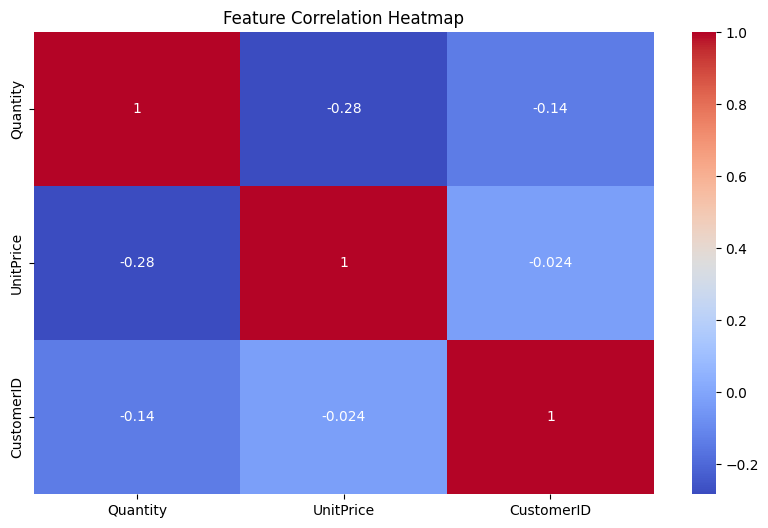

In [10]:
#Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [11]:
#Find most positively & negatively correlated pairs
corr_unstacked = corr.unstack().sort_values(ascending=False)
corr_unstacked = corr_unstacked[corr_unstacked != 1]  # remove self-correlations
most_pos = corr_unstacked.idxmax()
most_neg = corr_unstacked.idxmin()

print("\n🔹 Most positively correlated pair:", most_pos)
print("🔹 Most negatively correlated pair:", most_neg)



🔹 Most positively correlated pair: ('UnitPrice', 'CustomerID')
🔹 Most negatively correlated pair: ('UnitPrice', 'Quantity')
